# 实验十四：图像重建基础——雷登变换与 CT 模拟

## 一、知识点是什么？

雷登变换（Radon Transform）是把二维图像在不同方向上的线积分表示出来的方法。医学 CT 的扫描数据本质上就是这些投影数据，通常以**弦图（Sinogram）**形式表示。

在图像重建中：
- **正问题**：由原图得到各角度投影（Radon）
- **逆问题**：由投影恢复原图（重建）

本实验聚焦教材“实验十四”，帮助理解 CT 从采样到重建的核心数学流程。

## 二、实验目的

- 探究医学 CT 扫描的数学原理。
- 理解“投影 → 重建”的过程与误差来源。
- 对比简单反投影与滤波反投影（FBP）的重建效果。

## 三、实验内容（对应实验十四）

1. 对几何图像进行雷登变换，生成弦图（Sinogram）。
2. 实现简单反投影，观察星状伪影。
3. 实现滤波反投影（FBP），重建原始横截面图像。

## 四、导入库与实验设置

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from skimage import io, color
from skimage.data import shepp_logan_phantom
from skimage.transform import radon, iradon, resize
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.unicode_minus'] = False

## 五、生成实验图片素材

这里生成两类图像：
- Shepp-Logan 仿体（医学重建经典测试图像）
- 自定义几何图（圆、椭圆、条带），便于观察结构与投影关系

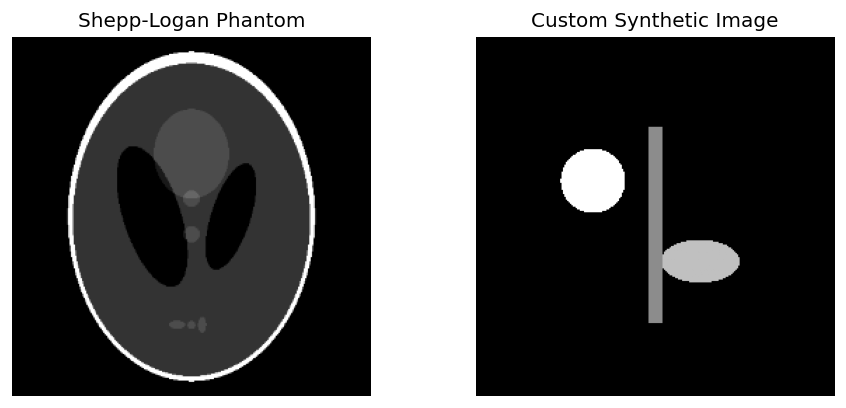

中间结果：
phantom shape = (256, 256) , range = (0.0, 1.0)
custom  shape = (256, 256) , range = (0.0, 1.0)


In [17]:
N = 256

# 1) Shepp-Logan 仿体
phantom = shepp_logan_phantom()
phantom = resize(phantom, (N, N), anti_aliasing=True)

# 2) 自定义几何图像
x = np.linspace(-1, 1, N)
X, Y = np.meshgrid(x, x)
custom = np.zeros((N, N), dtype=float)
custom[(X + 0.35)**2 + (Y + 0.2)**2 <= 0.18**2] = 1.0
custom[((X - 0.25)/0.22)**2 + ((Y - 0.25)/0.12)**2 <= 1.0] = 0.75
custom[(np.abs(X) < 0.04) & (Y > -0.5) & (Y < 0.6)] = 0.55

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
axes[0].imshow(phantom, cmap='gray')
axes[0].set_title('Shepp-Logan Phantom')
axes[0].axis('off')

axes[1].imshow(custom, cmap='gray')
axes[1].set_title('Custom Synthetic Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print('中间结果：')
print('phantom shape =', phantom.shape, ', range =', (float(phantom.min()), float(phantom.max())))
print('custom  shape =', custom.shape, ', range =', (float(custom.min()), float(custom.max())))

## 六、实验内容 1：雷登变换（Radon）与弦图（Sinogram）

对图像做多角度投影，得到 sinogram。

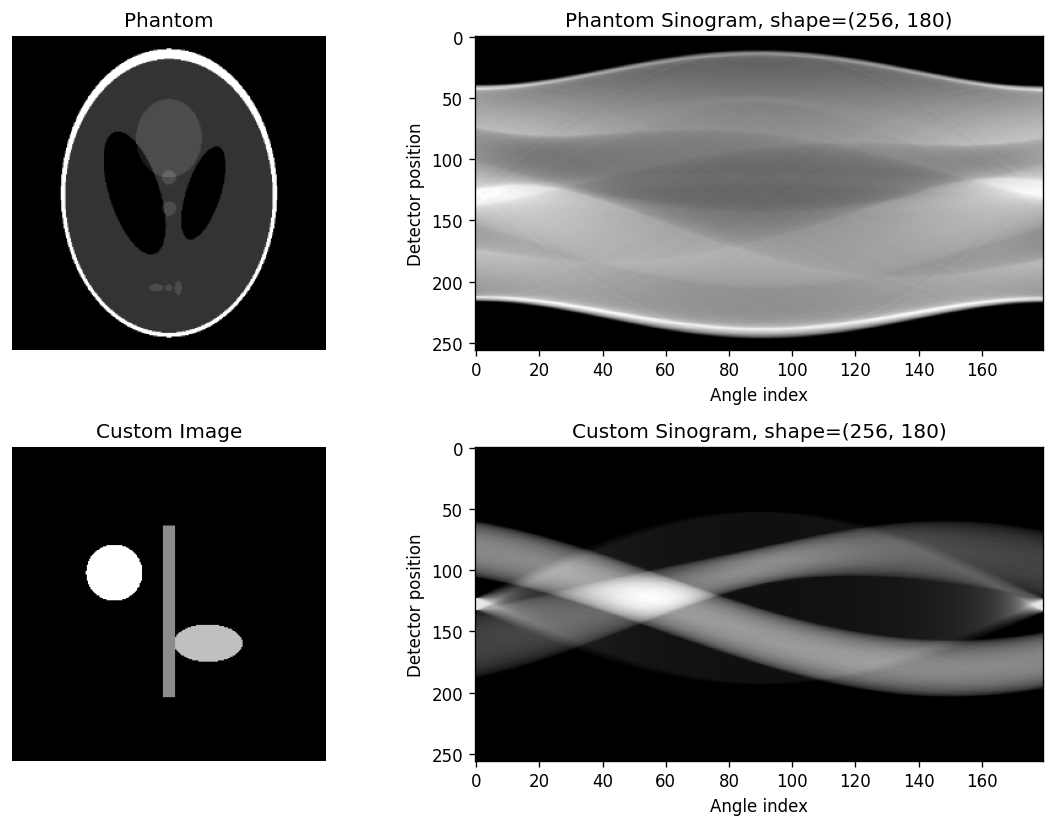

中间结果：
sinogram_phantom min/max = 0.0 66.20965682791761
sinogram_custom  min/max = 0.0 85.19455449155281


In [18]:
theta = np.linspace(0., 180., 180, endpoint=False)

sinogram_phantom = radon(phantom, theta=theta, circle=True)
sinogram_custom = radon(custom, theta=theta, circle=True)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes[0, 0].imshow(phantom, cmap='gray')
axes[0, 0].set_title('Phantom')
axes[0, 0].axis('off')

axes[0, 1].imshow(sinogram_phantom, cmap='gray', aspect='auto')
axes[0, 1].set_title(f'Phantom Sinogram, shape={sinogram_phantom.shape}')
axes[0, 1].set_xlabel('Angle index')
axes[0, 1].set_ylabel('Detector position')

axes[1, 0].imshow(custom, cmap='gray')
axes[1, 0].set_title('Custom Image')
axes[1, 0].axis('off')

axes[1, 1].imshow(sinogram_custom, cmap='gray', aspect='auto')
axes[1, 1].set_title(f'Custom Sinogram, shape={sinogram_custom.shape}')
axes[1, 1].set_xlabel('Angle index')
axes[1, 1].set_ylabel('Detector position')

plt.tight_layout()
plt.show()

print('中间结果：')
print('sinogram_phantom min/max =', float(sinogram_phantom.min()), float(sinogram_phantom.max()))
print('sinogram_custom  min/max =', float(sinogram_custom.min()), float(sinogram_custom.max()))

## 七、实验内容 2：简单反投影（Unfiltered Back Projection）

这里我们把滤波关闭，直接反投影。你会看到典型的**星状伪影**。

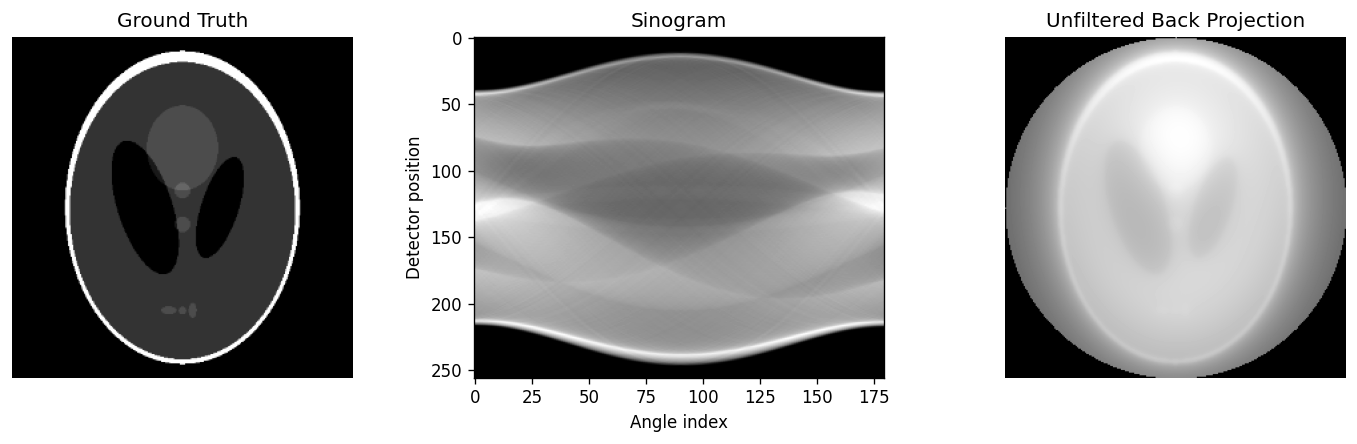

中间结果：
recon_bp shape = (256, 256)
recon_bp min/max = 0.0 74.35243838466288


In [19]:
# 未滤波反投影（简单反投影）
recon_bp = iradon(sinogram_phantom, theta=theta, circle=True, filter_name=None)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
axes[0].imshow(phantom, cmap='gray')
axes[0].set_title('Ground Truth')
axes[0].axis('off')

axes[1].imshow(sinogram_phantom, cmap='gray', aspect='auto')
axes[1].set_title('Sinogram')
axes[1].set_xlabel('Angle index')
axes[1].set_ylabel('Detector position')

axes[2].imshow(recon_bp, cmap='gray')
axes[2].set_title('Unfiltered Back Projection')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print('中间结果：')
print('recon_bp shape =', recon_bp.shape)
print('recon_bp min/max =', float(recon_bp.min()), float(recon_bp.max()))

## 八、实验内容 3：滤波反投影（FBP）

在反投影前做频域滤波（如 `ramp`），可显著抑制星状伪影，实现更准确重建。

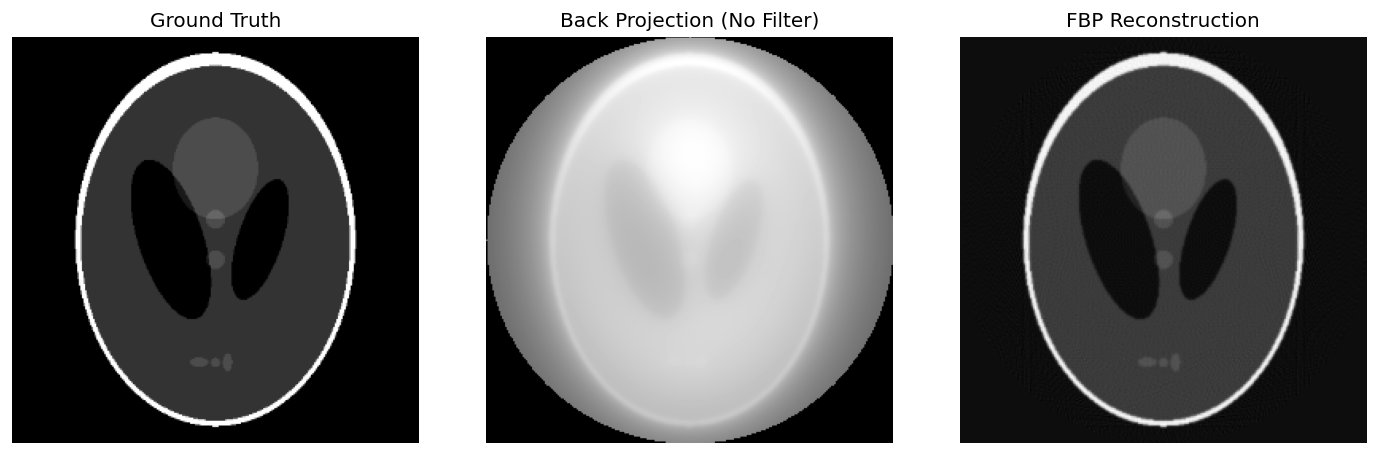

In [20]:
# FBP 重建（默认使用 ramp）
recon_fbp = iradon(sinogram_phantom, theta=theta, circle=True, filter_name='ramp')

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
axes[0].imshow(phantom, cmap='gray')
axes[0].set_title('Ground Truth')
axes[0].axis('off')

axes[1].imshow(recon_bp, cmap='gray')
axes[1].set_title('Back Projection (No Filter)')
axes[1].axis('off')

axes[2].imshow(recon_fbp, cmap='gray')
axes[2].set_title('FBP Reconstruction')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 九、必要中间结果与定量评估

为了直观比较“简单反投影”和“FBP”，我们输出三个指标：
- PSNR（越大越好）
- SSIM（越接近 1 越好）
- RMSE（越小越好）

In [21]:
def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def evaluate(gt, pred):
    dr = float(gt.max() - gt.min())
    return {
        'PSNR': float(psnr(gt, pred, data_range=dr)),
        'SSIM': float(ssim(gt, pred, data_range=dr)),
        'RMSE': rmse(gt, pred)
    }

m_bp = evaluate(phantom, recon_bp)
m_fbp = evaluate(phantom, recon_fbp)

print(f"{'Method':<24} {'PSNR':>10} {'SSIM':>10} {'RMSE':>10}")
print('-' * 60)
print(f"{'BackProjection(NoFilter)':<24} {m_bp['PSNR']:>10.3f} {m_bp['SSIM']:>10.4f} {m_bp['RMSE']:>10.4f}")
print(f"{'FBP(ramp)':<24} {m_fbp['PSNR']:>10.3f} {m_fbp['SSIM']:>10.4f} {m_fbp['RMSE']:>10.4f}")

improved = (m_fbp['PSNR'] > m_bp['PSNR']) and (m_fbp['RMSE'] < m_bp['RMSE'])
print('\n结论：', 'FBP 相比简单反投影有明显改进 ✅' if improved else '请检查参数设置 ⚠️')

Method                         PSNR       SSIM       RMSE
------------------------------------------------------------
BackProjection(NoFilter)    -33.906     0.1497    49.5800
FBP(ramp)                    30.775     0.9218     0.0289

结论： FBP 相比简单反投影有明显改进 ✅


## 十、实验结论（课堂讨论）

- 雷登变换将空间域结构映射为角度-探测器域的投影数据（sinogram）。
- 简单反投影会出现明显星状伪影。
- 滤波反投影（FBP）能有效抑制伪影并重建出更接近原图的结果。

## 十一、拓展与思考（附解答思路）

### 思考题 1：如果只使用 30 个角度进行重建，会怎样？
**解答思路：**
- 将 `theta` 改为 `np.linspace(0., 180., 30, endpoint=False)`。
- 对比无滤波反投影和 FBP 的结果。
- 预期欠采样会导致条纹伪影增强，细节信息丢失。

### 思考题 2：为什么 FBP 要先滤波再反投影？
**解答思路：**
- 反投影会把低频过度叠加，导致模糊和伪影。
- 滤波（如 ramp）用于补偿频谱失真，提升边缘细节。

### 思考题 3：FBP 是否一定“完美重建”？
**解答思路：**
- 在理想条件（充足角度、无噪声、准确模型）下可非常接近原图。
- 实际中受噪声、散射、角度不足影响，重建会偏离理想状态。

### 思考题 4（进阶）：如何进一步提升低剂量 CT 重建质量？
**解答思路：**
- 从“模型先验”角度引入正则化（如 TV）。
- 从“数据驱动”角度尝试深度学习重建网络。
- 对比指标可继续采用 PSNR/SSIM/RMSE。

## 十二、案例应用：读取你本地任意图片路径进行 CT 模拟重建

本模块支持学生直接替换本地图片路径做实验：
1. 修改 `image_path` 为你的图片文件路径；
2. 程序自动读取图片（彩色图会自动转灰度）；
3. 依次完成 Radon、简单反投影、FBP，并输出中间结果与指标。

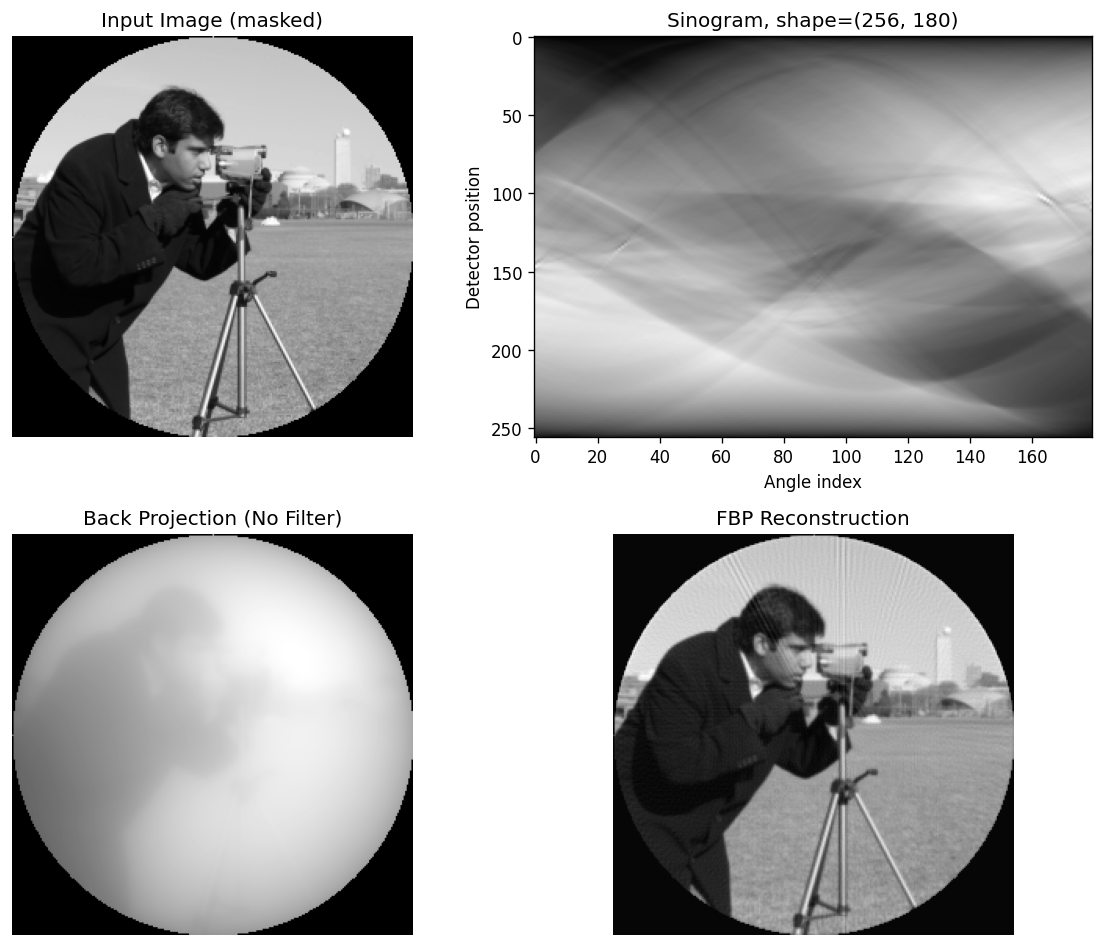

中间结果：
读取图片路径： D:\xiangmu\shutu\14-\case_image_camera_masked.png
预处理后保存到： D:\xiangmu\shutu\14-\case_image_loaded_masked.png
case_img_ct shape = (256, 256) , range = (0.0, 1.0)
case_sino shape = (256, 180) , min/max = (0.0, 176.74904021181158)

指标对比（圆形区域）：
Method                         PSNR       SSIM       RMSE
------------------------------------------------------------
BackProjection(NoFilter)    -44.414     0.1492   164.9301
FBP(ramp)                    29.930     0.9038     0.0316

结论： 在给定图片上，FBP 重建优于简单反投影 ✅


In [28]:
# 1) 读取本地任意图片（学生只需改这个路径）
image_path = r'D:\xiangmu\shutu\14-\case_image_camera_masked.png'
img_path = Path(image_path)
if not img_path.exists():
    raise FileNotFoundError(f'图片不存在，请检查路径：{img_path}')

img = io.imread(str(img_path))
if img.ndim == 3:
    if img.shape[2] == 4:
        img = img[:, :, :3]
    img = color.rgb2gray(img)

img = img.astype(np.float64)
if img.max() > 1.0:
    img = img / 255.0

case_img = resize(img, (256, 256), anti_aliasing=True)

# 为满足 circle=True 的几何假设：将重建圆外区域置零
h, w = case_img.shape
yy, xx = np.ogrid[:h, :w]
cy, cx = h / 2, w / 2
r = min(h, w) / 2
circle_mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= r ** 2
case_img_ct = case_img.copy()
case_img_ct[~circle_mask] = 0.0

# 可选：保存预处理后的案例图
save_path = r'D:\xiangmu\shutu\14-\case_image_loaded_masked.png'
plt.imsave(save_path, case_img_ct, cmap='gray')

# 2) Radon 变换
theta_case = np.linspace(0., 180., 180, endpoint=False)
case_sino = radon(case_img_ct, theta=theta_case, circle=True)

# 3) 简单反投影（无滤波）与 FBP
case_bp = iradon(case_sino, theta=theta_case, circle=True, filter_name=None)
case_fbp = iradon(case_sino, theta=theta_case, circle=True, filter_name='ramp')

# 4) 指标评估（在圆形重建区域内计算，更公平）
def eval_case(gt, pred, mask):
    gt_m = gt[mask]
    pred_m = pred[mask]
    dr = float(gt_m.max() - gt_m.min())
    return {
        'PSNR': float(psnr(gt_m, pred_m, data_range=dr)),
        'SSIM': float(ssim(gt, pred, data_range=float(gt.max() - gt.min()))),
        'RMSE': float(np.sqrt(np.mean((gt_m - pred_m) ** 2)))
    }

m_case_bp = eval_case(case_img_ct, case_bp, circle_mask)
m_case_fbp = eval_case(case_img_ct, case_fbp, circle_mask)

# 5) 可视化
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(case_img_ct, cmap='gray')
axes[0, 0].set_title('Input Image (masked)')
axes[0, 0].axis('off')

axes[0, 1].imshow(case_sino, cmap='gray', aspect='auto')
axes[0, 1].set_title(f'Sinogram, shape={case_sino.shape}')
axes[0, 1].set_xlabel('Angle index')
axes[0, 1].set_ylabel('Detector position')

axes[1, 0].imshow(case_bp, cmap='gray')
axes[1, 0].set_title('Back Projection (No Filter)')
axes[1, 0].axis('off')

axes[1, 1].imshow(case_fbp, cmap='gray')
axes[1, 1].set_title('FBP Reconstruction')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# 6) 输出中间结果与结论
print('中间结果：')
print('读取图片路径：', str(img_path))
print('预处理后保存到：', save_path)
print('case_img_ct shape =', case_img_ct.shape, ', range =', (float(case_img_ct.min()), float(case_img_ct.max())))
print('case_sino shape =', case_sino.shape, ', min/max =', (float(case_sino.min()), float(case_sino.max())))

print('\n指标对比（圆形区域）：')
print(f"{'Method':<24} {'PSNR':>10} {'SSIM':>10} {'RMSE':>10}")
print('-' * 60)
print(f"{'BackProjection(NoFilter)':<24} {m_case_bp['PSNR']:>10.3f} {m_case_bp['SSIM']:>10.4f} {m_case_bp['RMSE']:>10.4f}")
print(f"{'FBP(ramp)':<24} {m_case_fbp['PSNR']:>10.3f} {m_case_fbp['SSIM']:>10.4f} {m_case_fbp['RMSE']:>10.4f}")

case_ok = (m_case_fbp['PSNR'] > m_case_bp['PSNR']) and (m_case_fbp['RMSE'] < m_case_bp['RMSE'])
print('\n结论：', '在给定图片上，FBP 重建优于简单反投影 ✅' if case_ok else '请检查角度或滤波参数 ⚠️')